In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("32130_2026A_70.csv")
df.head()

,source ID,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,...,loan_purpose,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,num_of_delinquencies,loan_paid_back
0,6839,43,Female,Married,Bachelor's,32234.10,2686.18,Employed,0.112,793,...,Other,10.10,60,413.09,2,48020.45,44962.33,2,2,1
1,7570,65,Female,Married,Bachelor's,68415.70,5701.31,Employed,0.185,614,...,Debt consolidation,9.45,36,878.20,4,68629.07,56979.84,3,4,1
2,18316,64,Male,Married,High School,31068.24,2589.02,Unemployed,0.169,651,...,Other,15.89,36,218.08,5,47495.46,22534.57,3,5,0
3,13921,22,Male,Single,Bachelor's,19876.34,1656.36,Retired,0.201,701,...,Education,9.81,36,351.42,4,32537.55,30802.20,2,4,1
4,12410,30,Female,Married,High School,28948.26,2412.36,Employed,0.032,709,...,Car,10.89,60,42.87,3,34851.99,26439.27,1,1,1


In [5]:
print(df.columns.tolist())
print(df.shape)

['source ID', 'age', 'gender', 'marital_status', 'education_level', 'annual_income', 'monthly_income', 'employment_status', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies', 'loan_paid_back']
(3000, 21)


In [6]:
original_columns = [
    'source ID',
    'age',
    'gender',
    'marital_status',
    'education_level',
    'annual_income',
    'monthly_income',
    'employment_status',
    'debt_to_income_ratio',
    'credit_score',
    'loan_amount',
    'loan_purpose',
    'interest_rate',
    'loan_term',
    'installment',
    'num_of_open_accounts',
    'total_credit_limit',
    'current_balance',
    'delinquency_history',
    'num_of_delinquencies',
    'loan_paid_back'
]

df = df[original_columns].copy()

In [7]:
numeric_cols = [
    'age',
    'annual_income',
    'monthly_income',
    'debt_to_income_ratio',
    'credit_score',
    'loan_amount',
    'interest_rate',
    'loan_term',
    'installment',
    'num_of_open_accounts',
    'total_credit_limit',
    'current_balance',
    'num_of_delinquencies'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
categorical_cols = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'delinquency_history',
    'loan_paid_back'
]

In [9]:
os.makedirs("graphs/numeric", exist_ok=True)
os.makedirs("graphs/categorical", exist_ok=True)
os.makedirs("graphs/relationships", exist_ok=True)

Histogram — annual_income

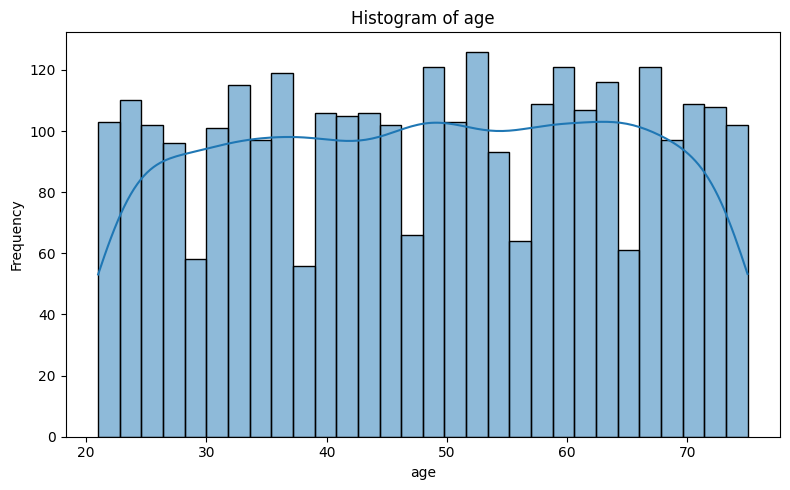

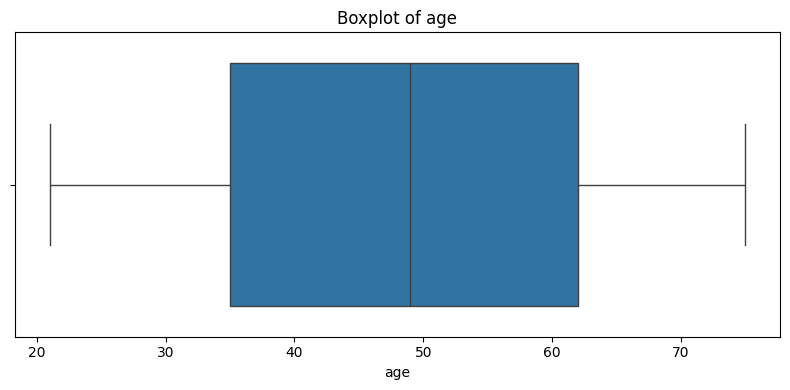

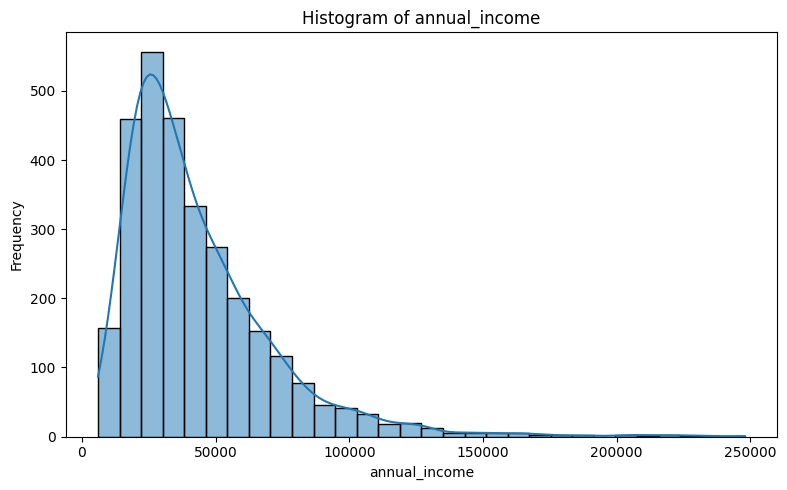

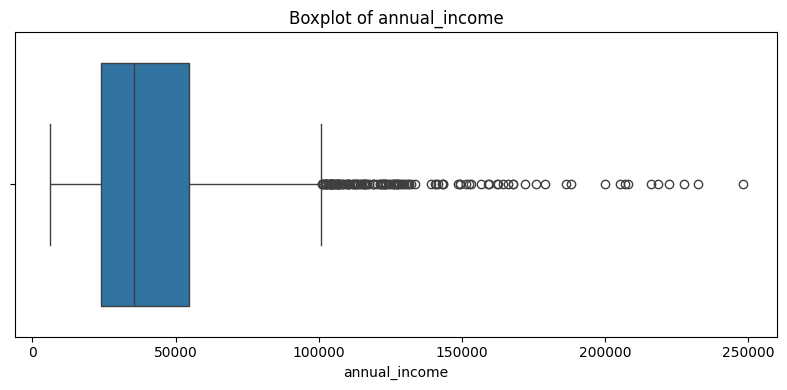

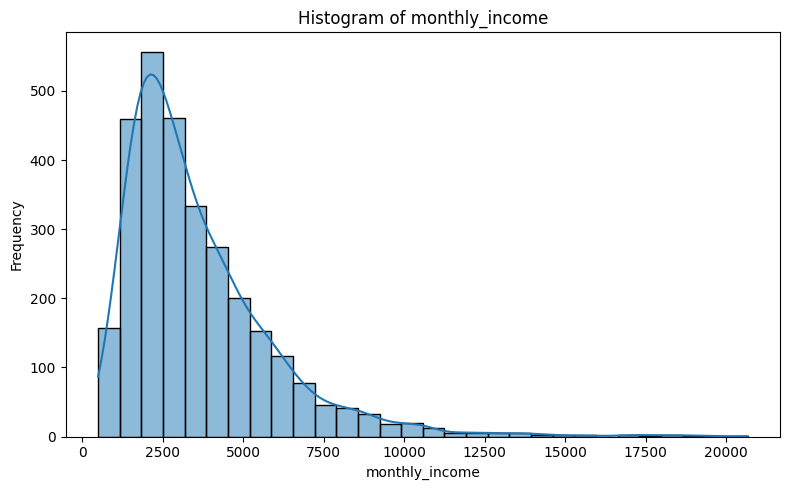

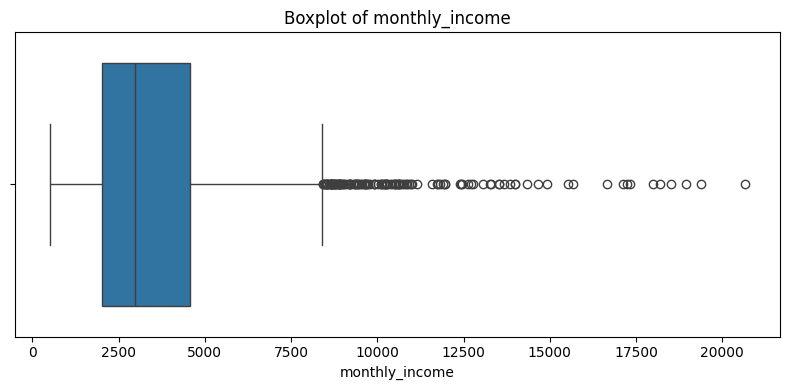

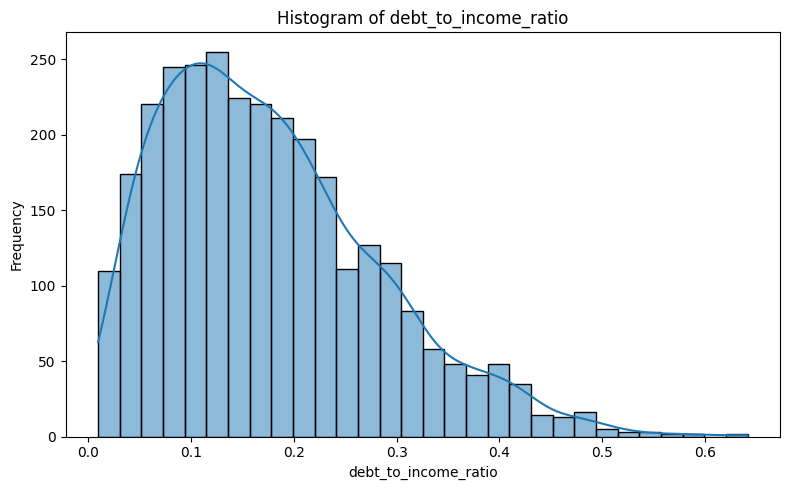

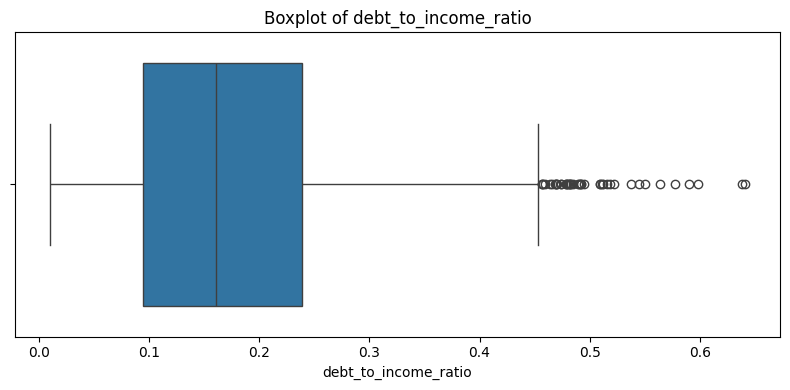

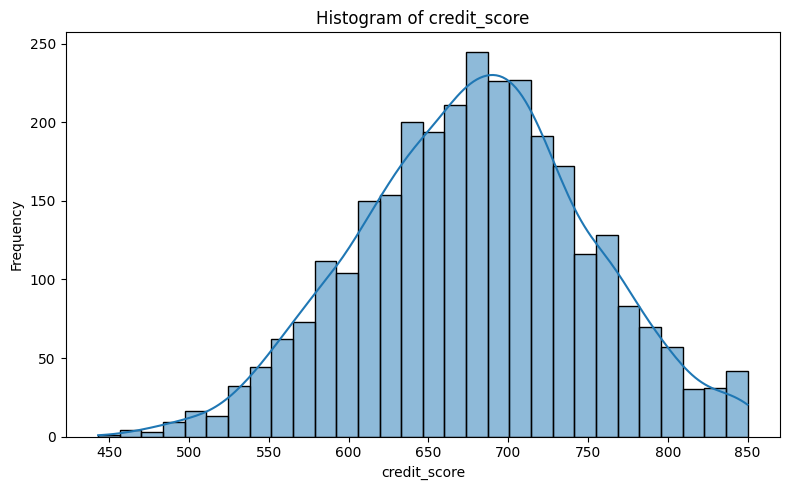

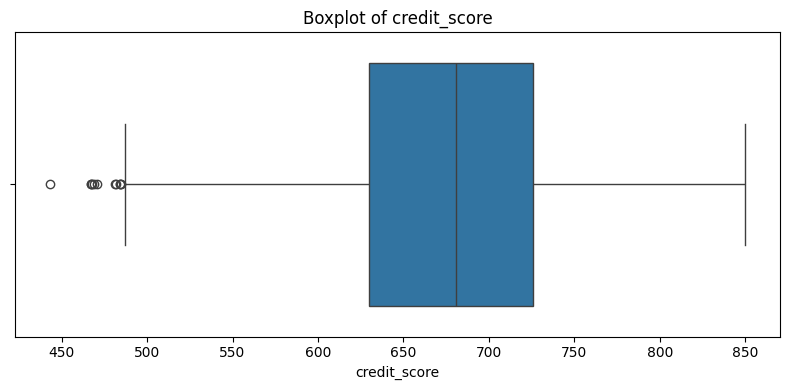

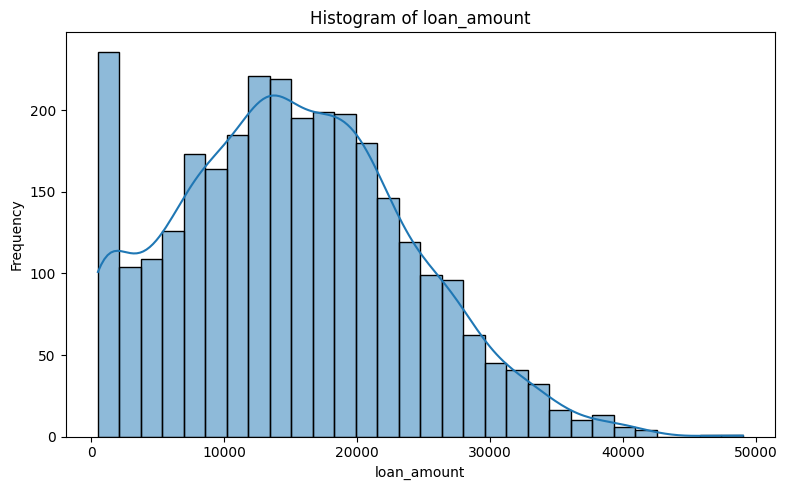

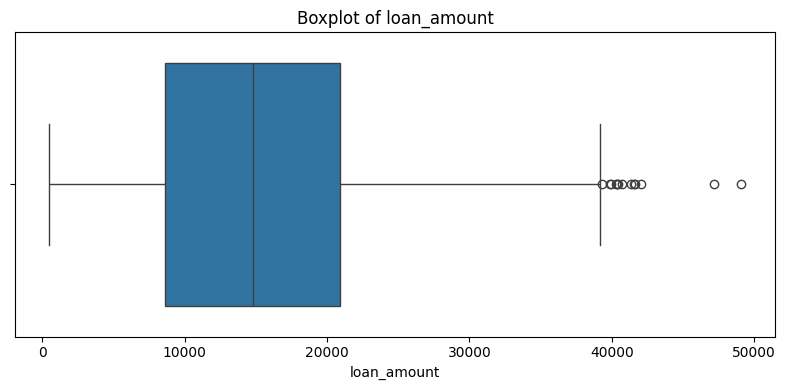

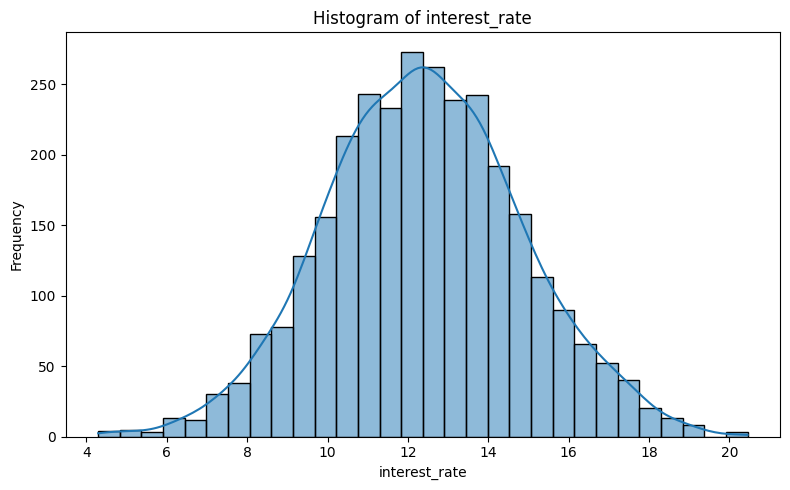

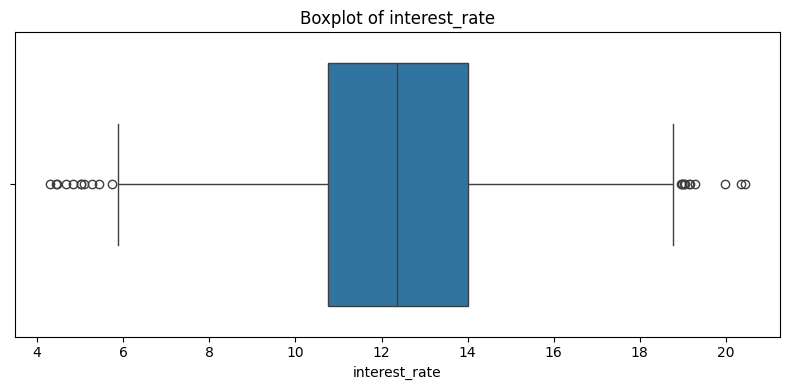

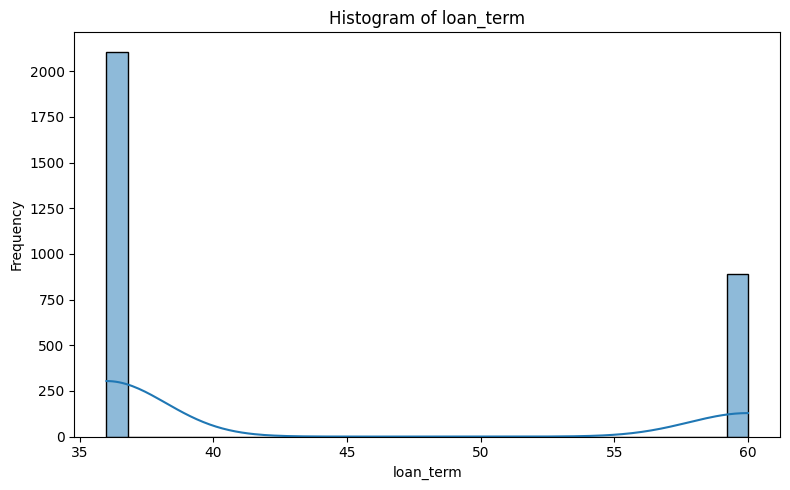

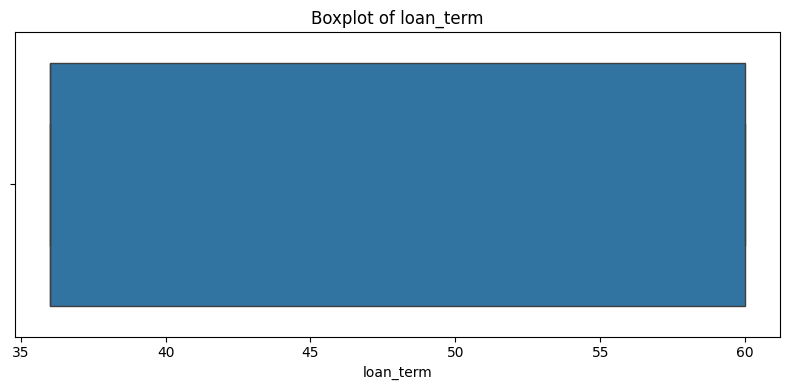

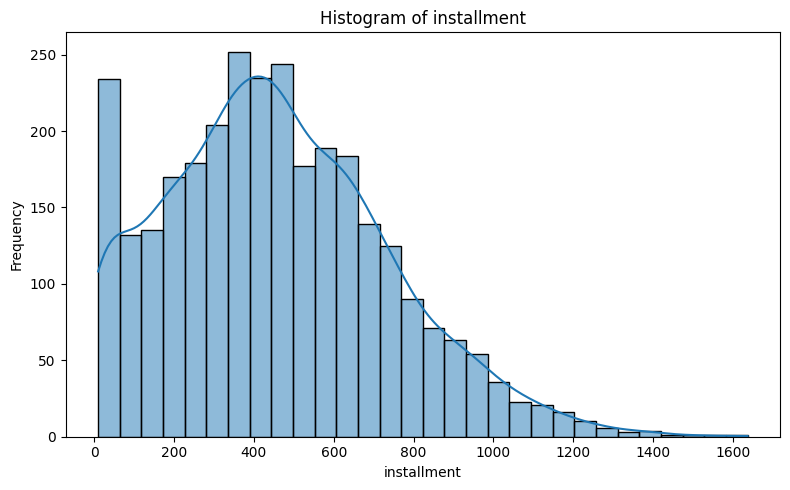

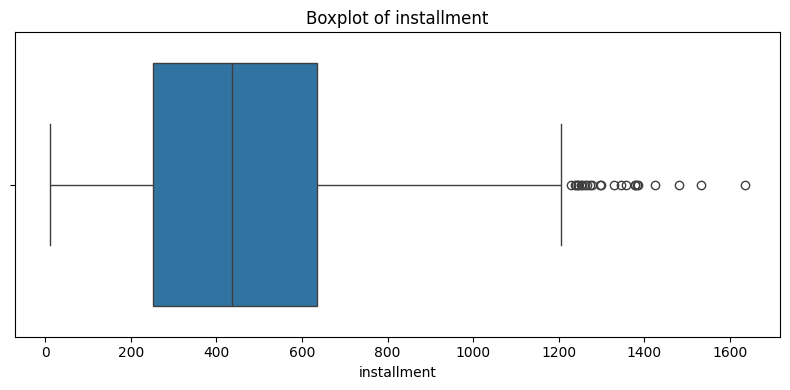

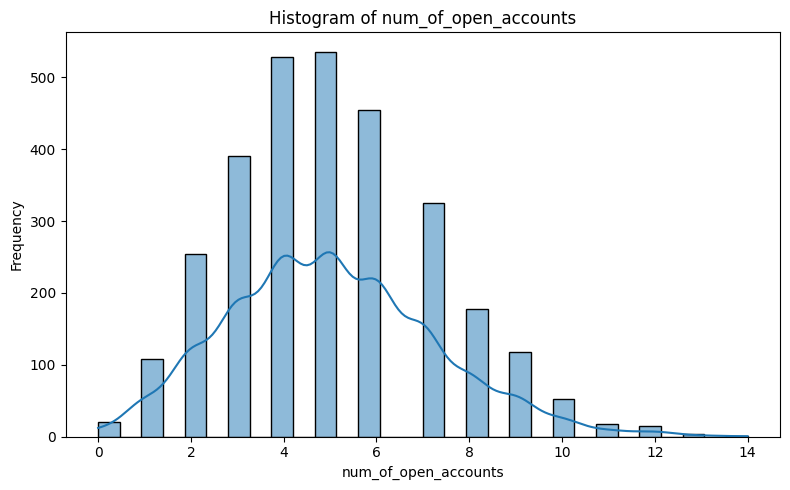

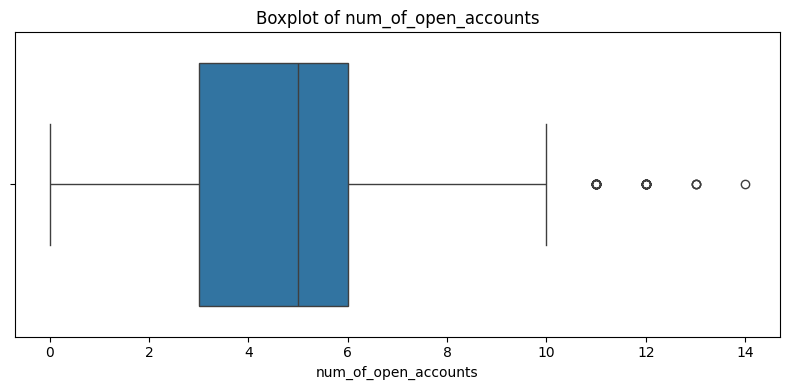

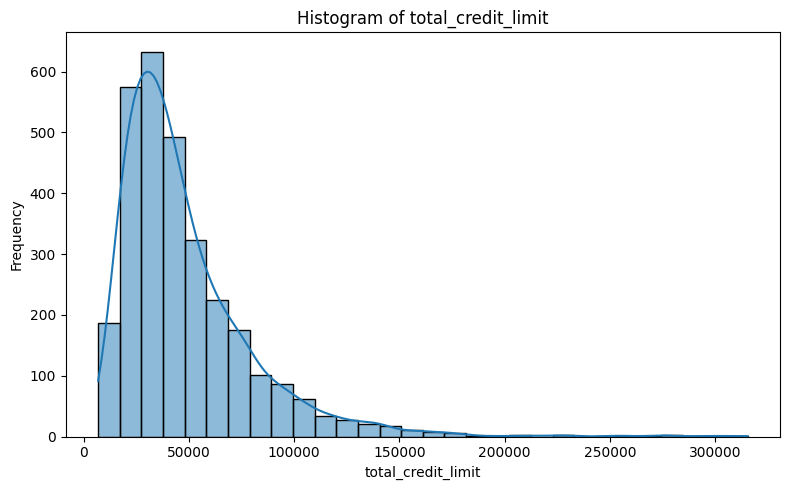

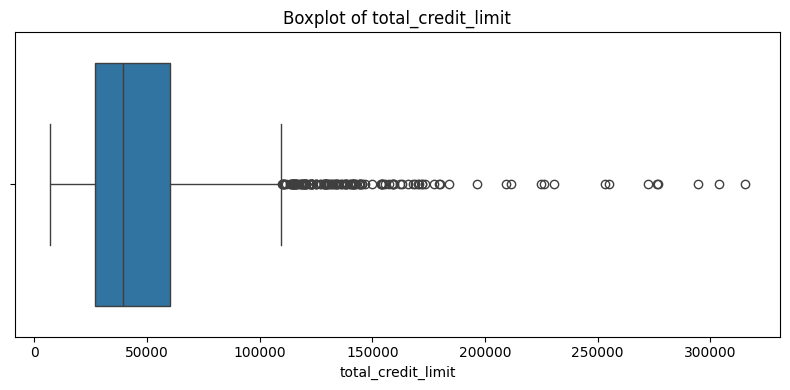

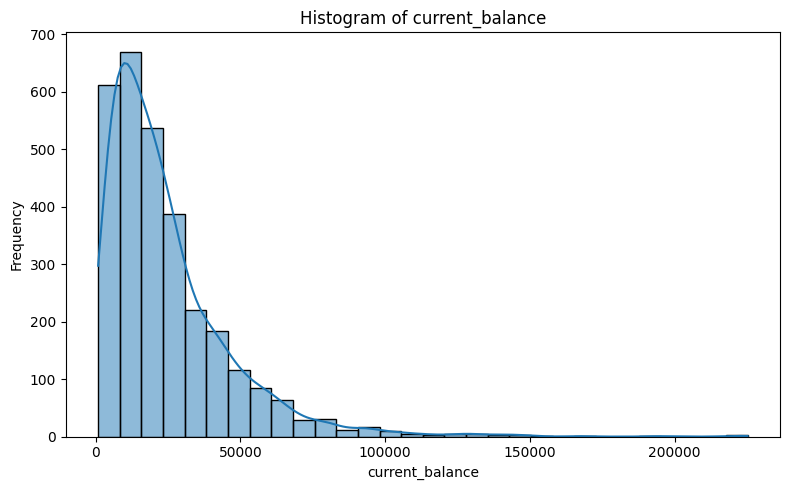

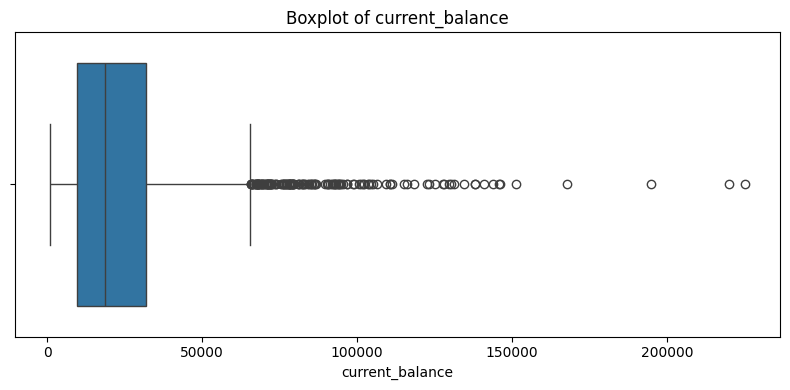

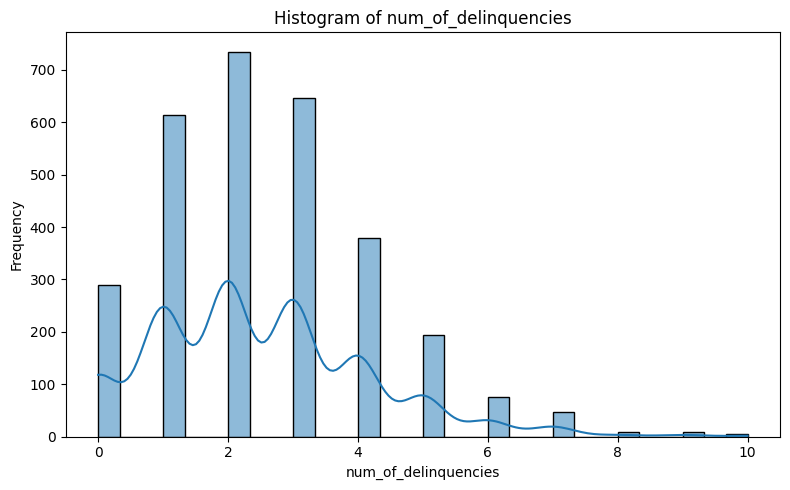

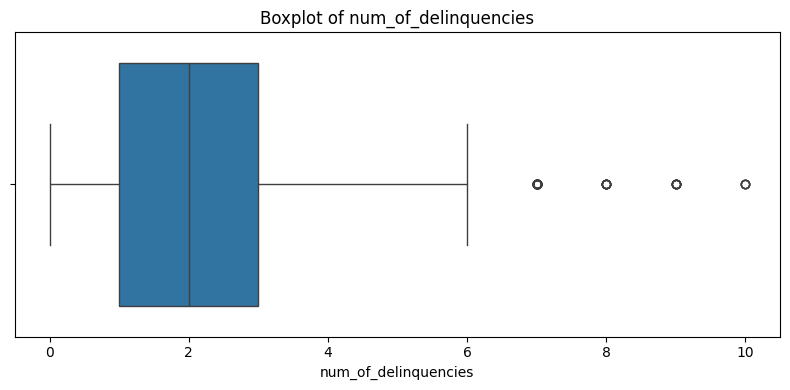

In [10]:
for col in numeric_cols:
    data = df[col].dropna()

    # Graph 1: Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'graphs/numeric/{col}_histogram.png')
    plt.show()

  
    # Graph 2: Boxplot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f'graphs/numeric/{col}_boxplot.png')
    plt.show()

All categorical attributes

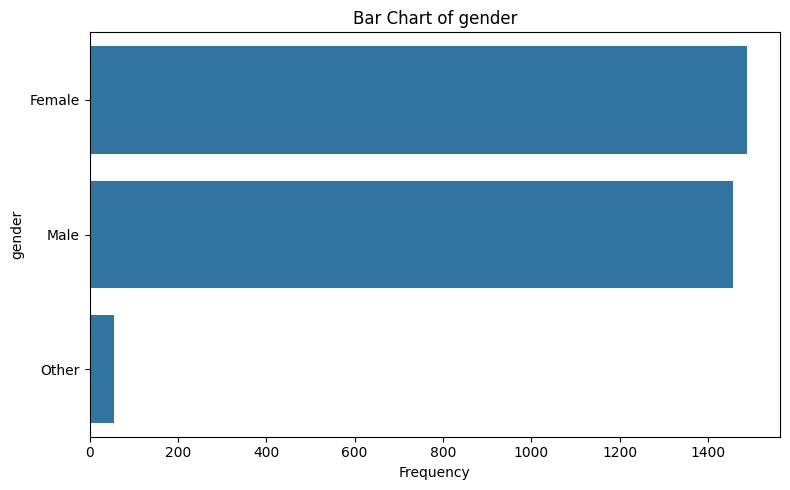

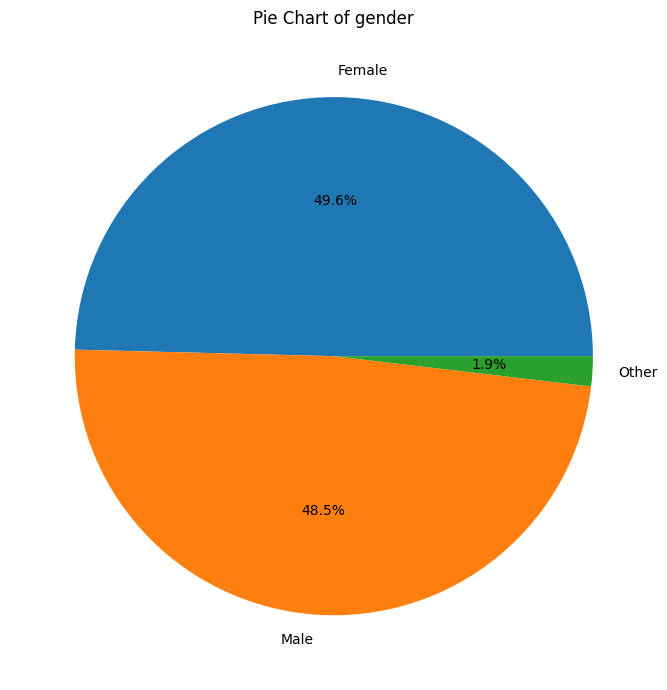

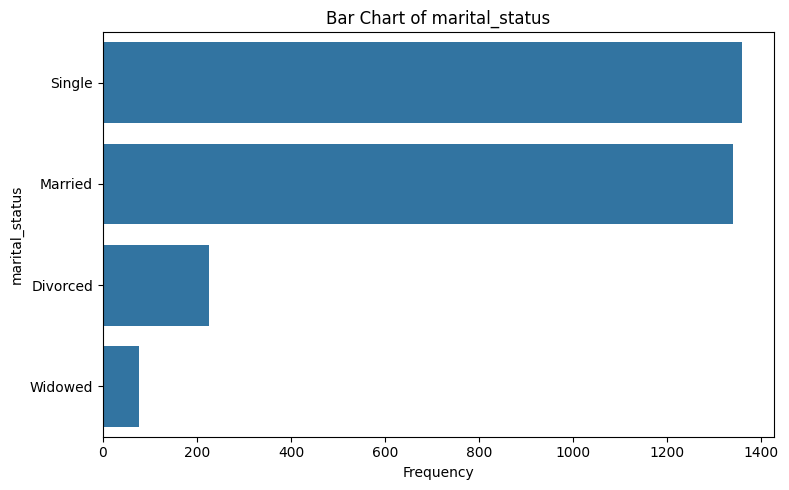

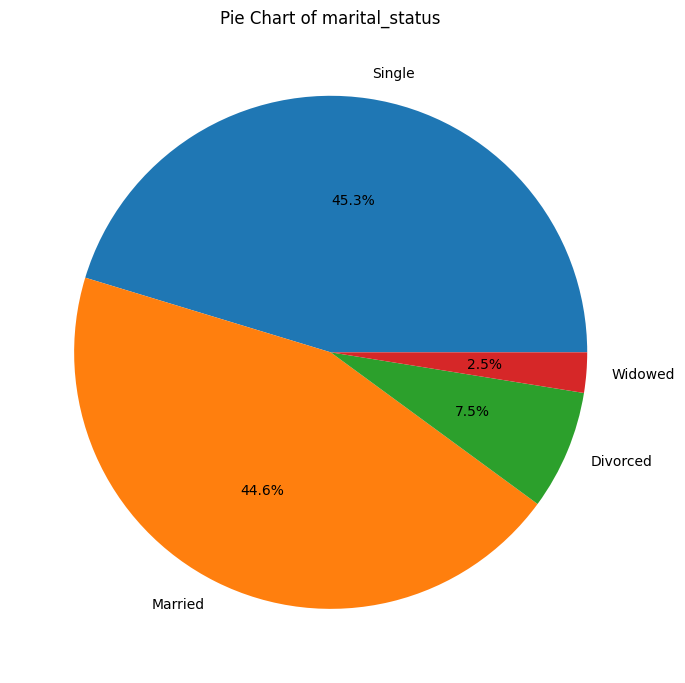

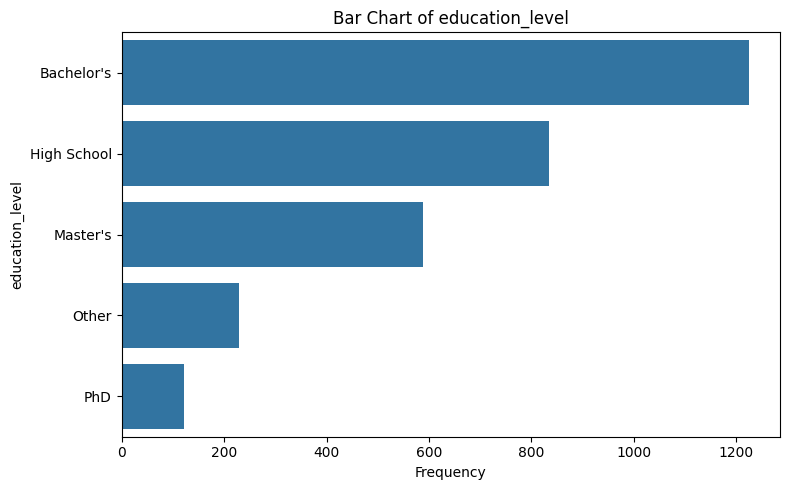

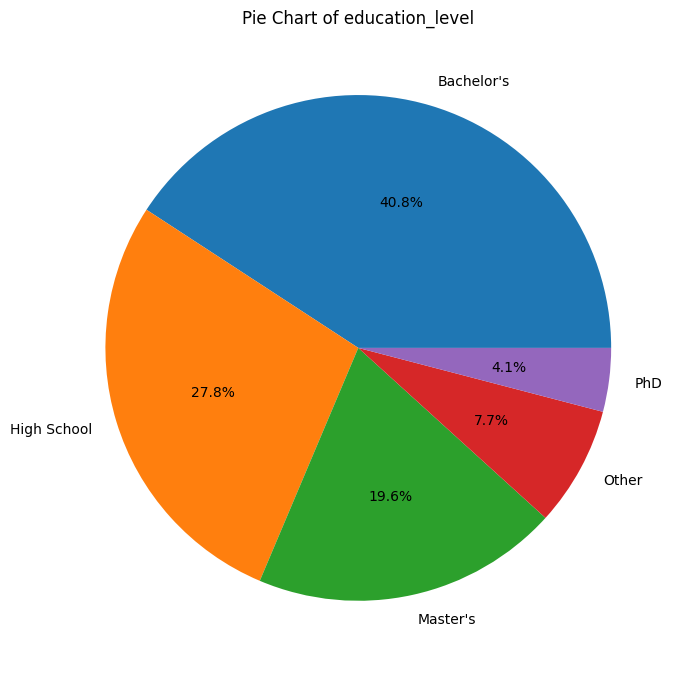

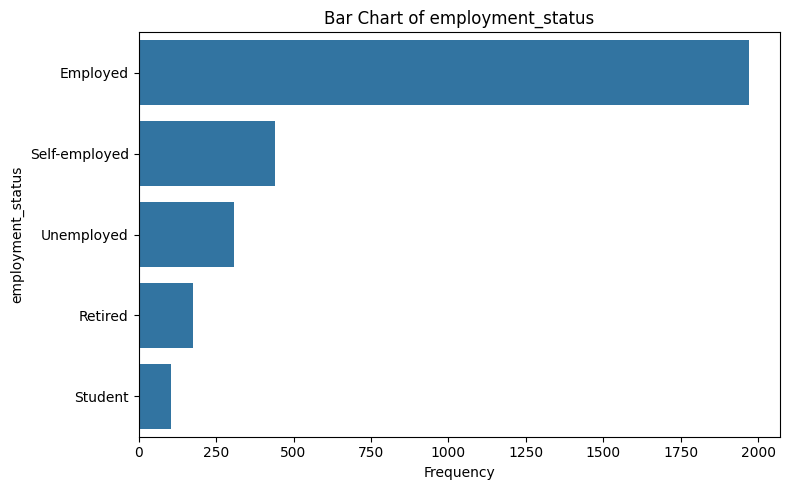

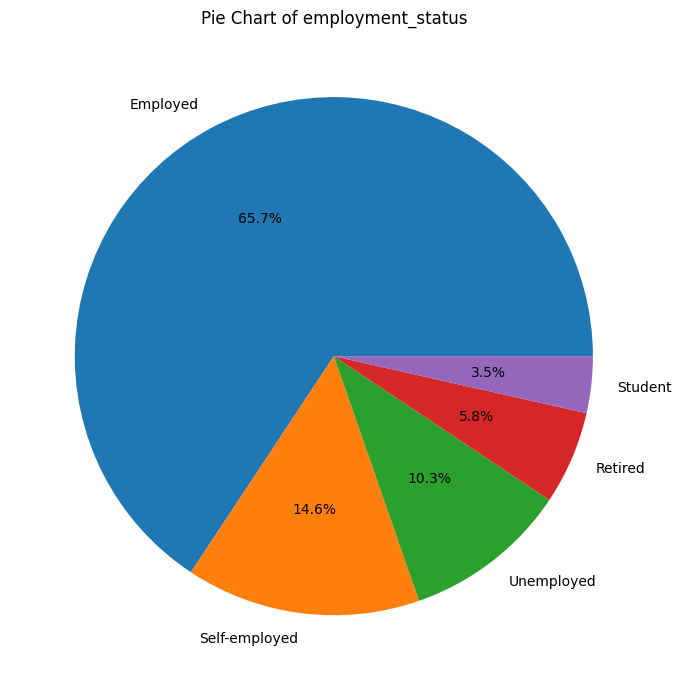

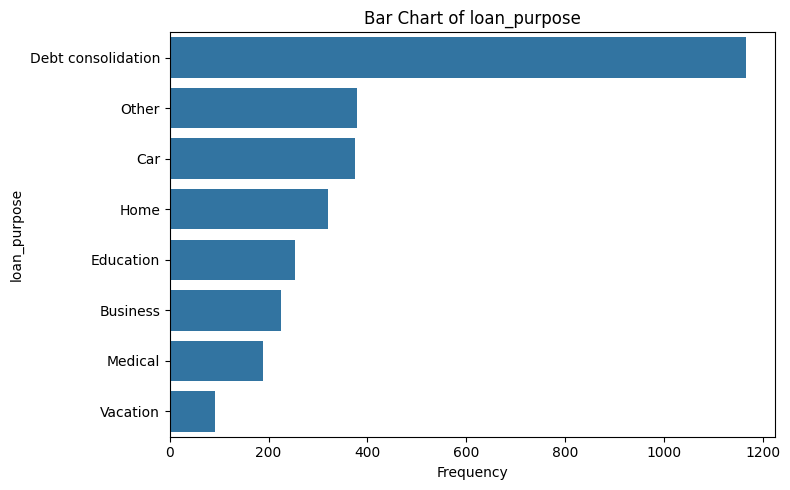

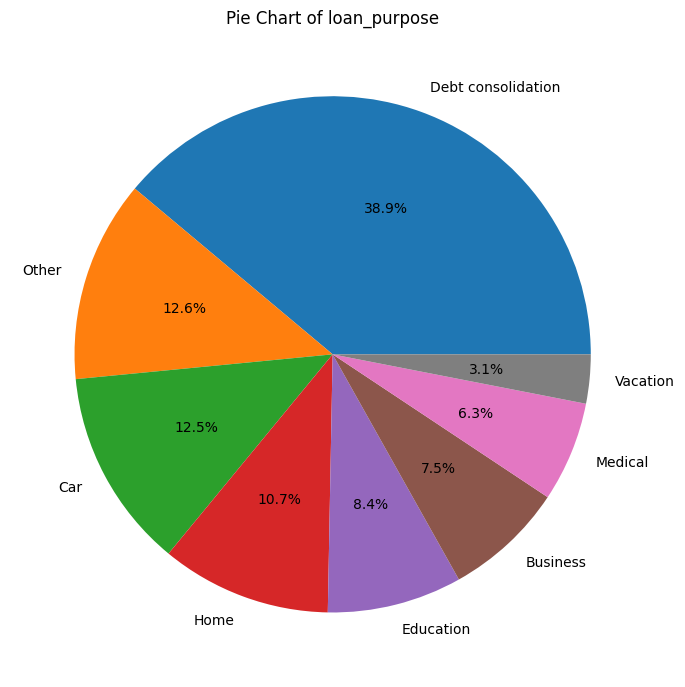

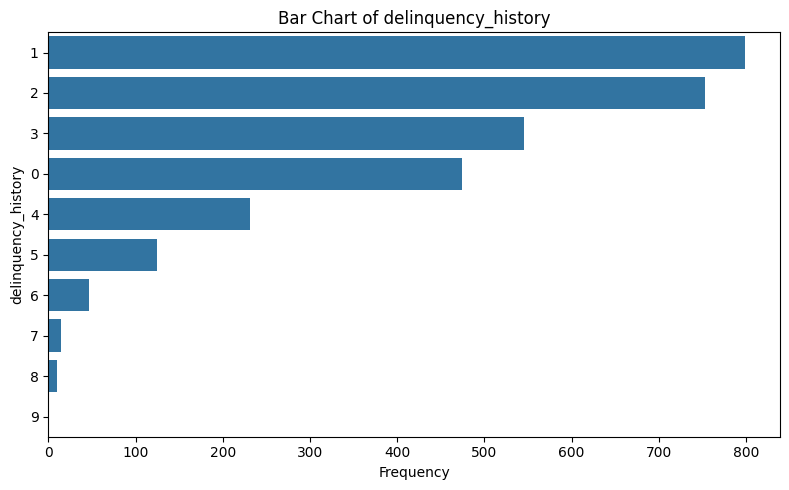

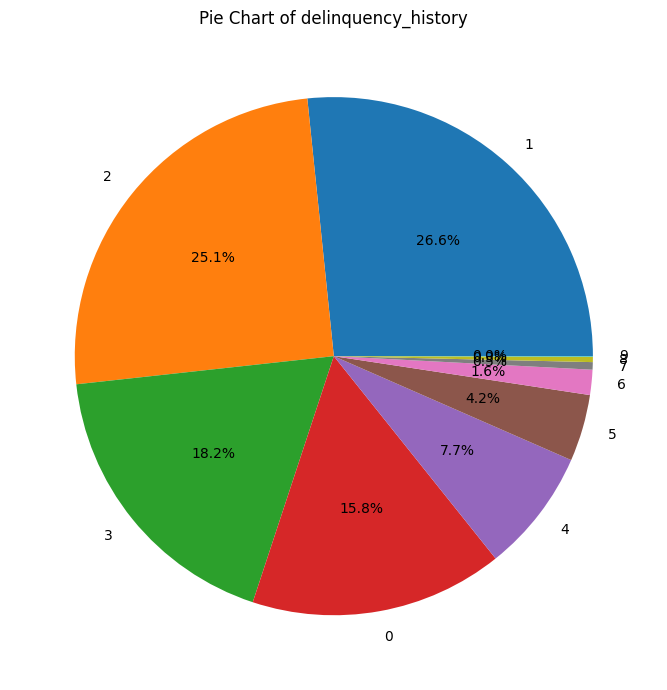

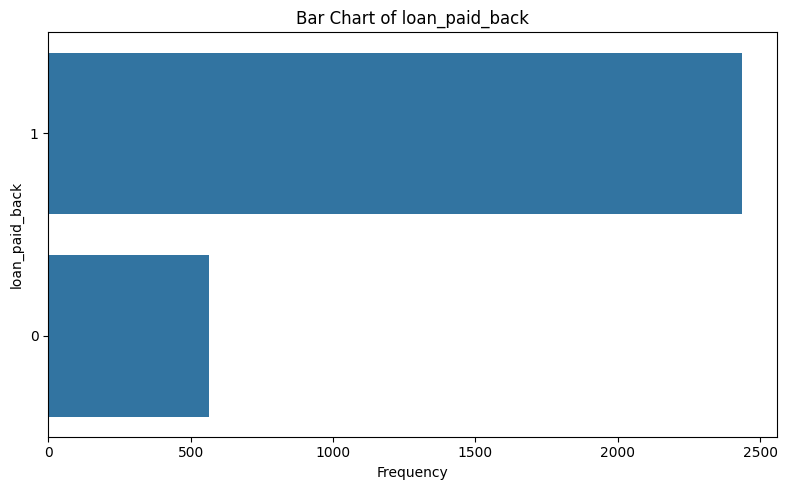

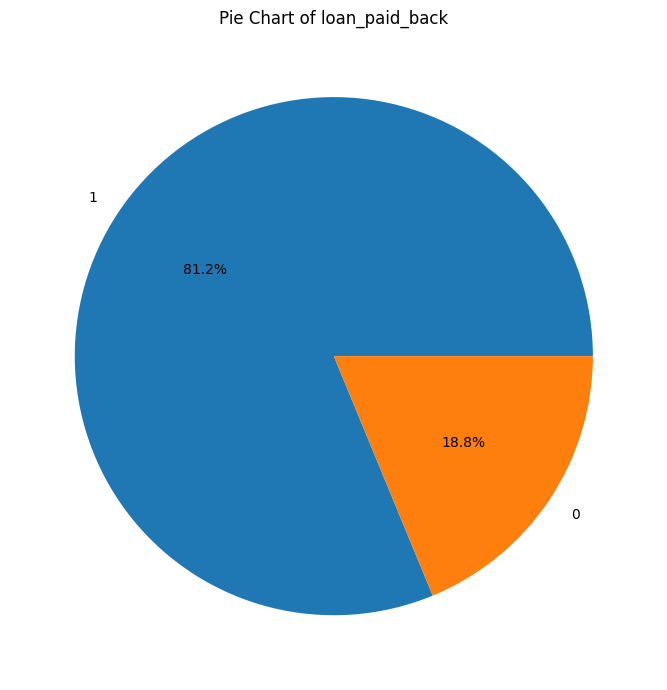

In [11]:
for col in categorical_cols:
    data = df[col].dropna()

    # Value counts
    counts = data.value_counts()

    # Graph 1: Bar chart
    plt.figure(figsize=(8, 5))
    sns.countplot(y=col, data=df, order=counts.index)
    plt.title(f'Bar Chart of {col}')
    plt.xlabel('Frequency')
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f'graphs/categorical/{col}_bar_chart.png')
    plt.show()

    # Graph 2: Pie chart
    plt.figure(figsize=(7, 7))
    counts.plot.pie(autopct='%1.1f%%')
    plt.title(f'Pie Chart of {col}')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(f'graphs/categorical/{col}_pie_chart.png')
    plt.show()

Correlation heatmap:

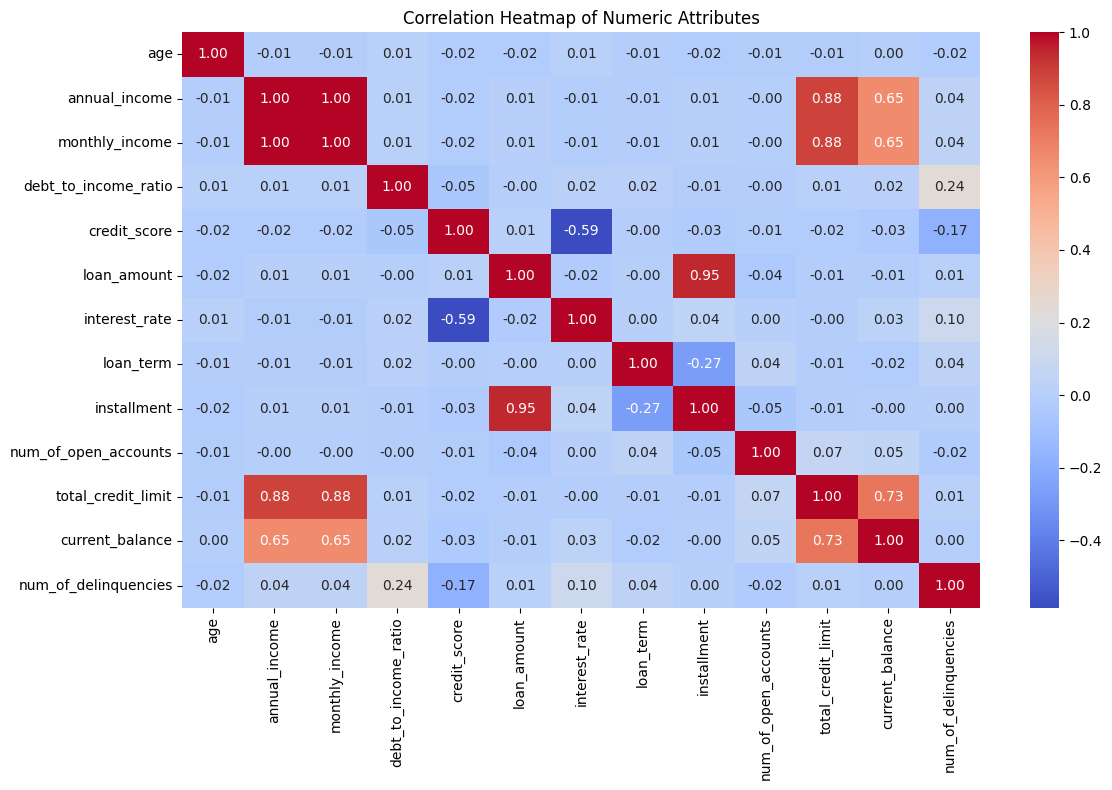

In [12]:
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Attributes")
plt.tight_layout()
plt.savefig("graphs/relationships/correlation_heatmap.png")
plt.show()

Scatter plots for important pairs:

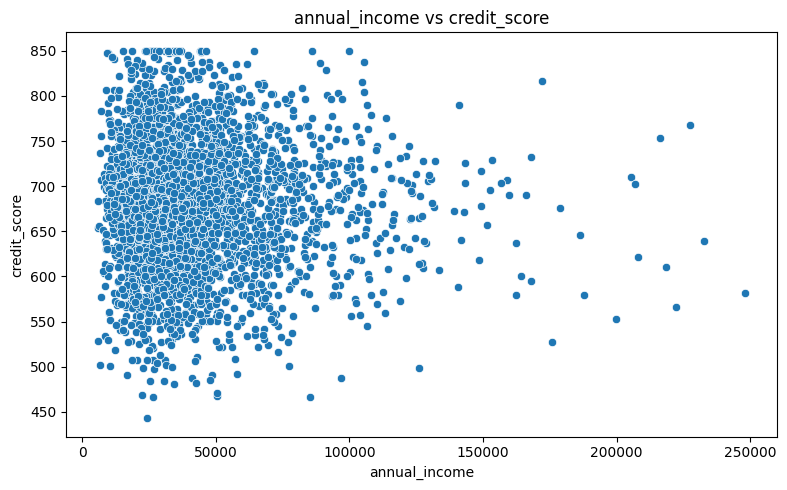

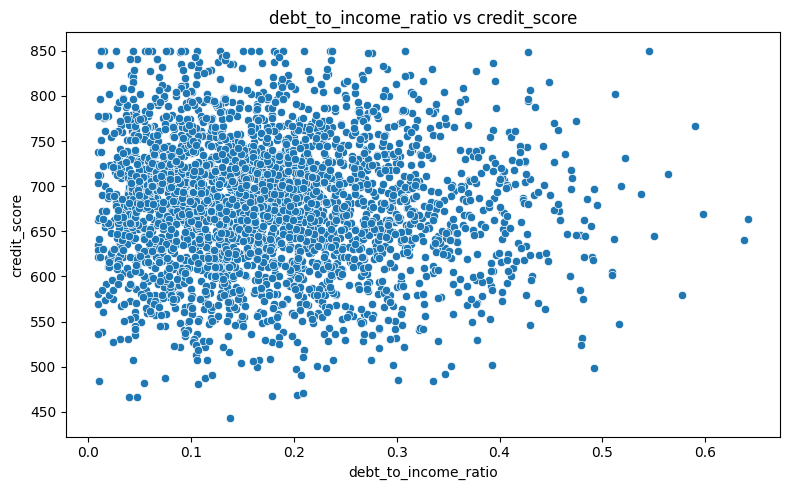

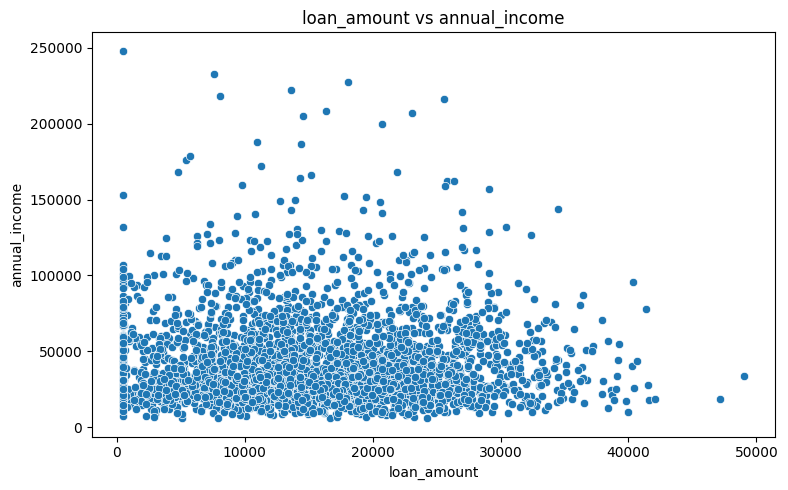

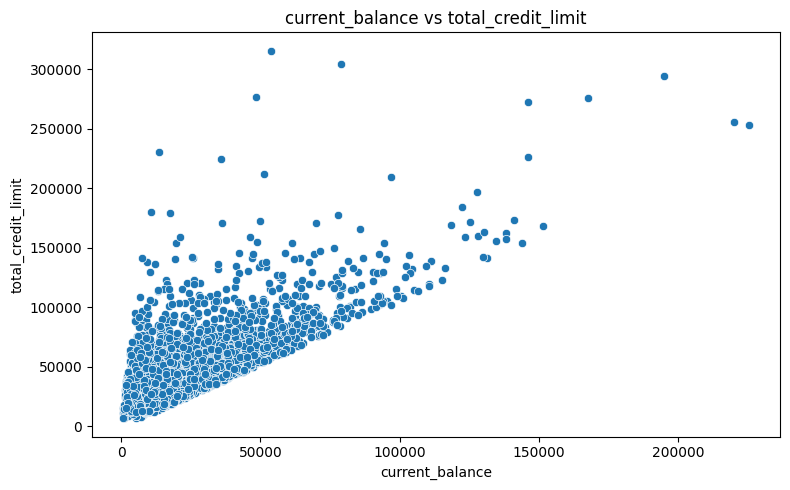

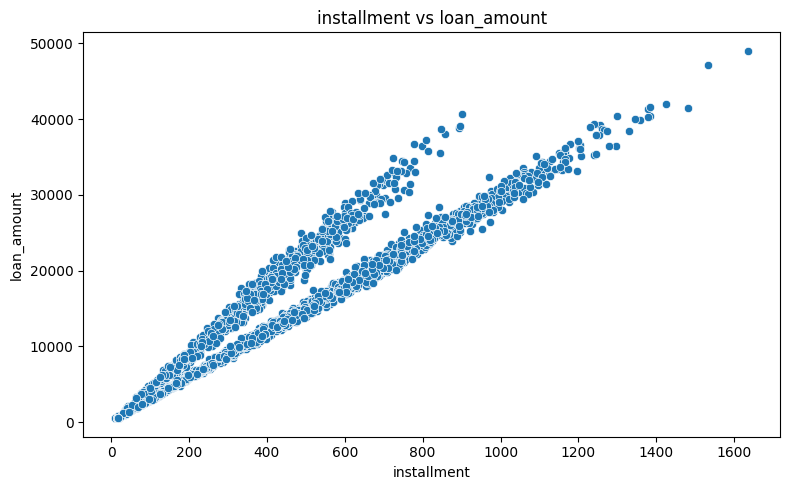

In [13]:
important_pairs = [
    ('annual_income', 'credit_score'),
    ('debt_to_income_ratio', 'credit_score'),
    ('loan_amount', 'annual_income'),
    ('current_balance', 'total_credit_limit'),
    ('installment', 'loan_amount')
]

for x_col, y_col in important_pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x_col, y=y_col)
    plt.title(f'{x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.savefig(f'graphs/relationships/{x_col}_vs_{y_col}.png')
    plt.show()

In [14]:
def classify_attribute_type(series):
    if pd.api.types.is_numeric_dtype(series):
        unique_vals = series.dropna().nunique()
        if unique_vals <= 10:
            return "Categorical / Discrete Numeric"
        else:
            return "Numerical"
    else:
        return "Categorical"

attribute_type_table = pd.DataFrame({
    "attribute": df.columns,
    "attribute_type": [classify_attribute_type(df[col]) for col in df.columns],
    "missing_values": [df[col].isna().sum() for col in df.columns],
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})

attribute_type_table.head()

,attribute,attribute_type,missing_values,unique_values
0,source ID,Numerical,0,3000
1,age,Numerical,0,55
2,gender,Categorical,0,3
3,marital_status,Categorical,0,4
4,education_level,Categorical,0,5


In [16]:
attribute_type_table.to_excel("attribute_type_table.xlsx", index=False)
print("attribute_type_table.xlsx created")

attribute_type_table.xlsx created


In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

summary_rows = []

for col in numeric_cols:
    summary_rows.append({
        "attribute": col,
        "count": df[col].count(),
        "missing": df[col].isna().sum(),
        "mean": df[col].mean(),
        "median": df[col].median(),
        "std": df[col].std(),
        "variance": df[col].var(),
        "min": df[col].min(),
        "25%": df[col].quantile(0.25),
        "50%": df[col].quantile(0.50),
        "75%": df[col].quantile(0.75),
        "max": df[col].max()
    })

numeric_summary = pd.DataFrame(summary_rows)
numeric_summary.head()

,attribute,count,missing,mean,median,std,variance,min,25%,50%,75%,max
0,source ID,3000,0,9933.679667,9846.500,5797.654390,3.361280e+07,0.00,4900.0000,9846.500,15028.2500,19993.000
1,age,3000,0,48.264667,49.000,15.700747,2.465135e+02,21.00,35.0000,49.000,62.0000,75.000
2,annual_income,3000,0,43240.170460,35565.045,28164.683868,7.932494e+08,6000.00,24083.7475,35565.045,54737.6200,247972.390
3,monthly_income,3000,0,3603.347423,2963.755,2347.057036,5.508677e+06,500.00,2006.9800,2963.755,4561.4675,20664.370
4,debt_to_income_ratio,3000,0,0.176754,0.161,0.105891,1.121288e-02,0.01,0.0950,0.161,0.2390,0.641


In [18]:
numeric_summary.to_excel("numeric_summary.xlsx", index=False)
print("numeric_summary.xlsx created")

numeric_summary.xlsx created


In [9]:
categorical_cols = [col for col in df.columns if df[col].dtype == "object"]

all_freq_tables = []

for col in categorical_cols:
    freq = df[col].fillna("Missing").value_counts(dropna=False).reset_index()
    freq.columns = ["category", "frequency"]
    freq.insert(0, "attribute", col)
    all_freq_tables.append(freq)

categorical_frequency_tables = pd.concat(all_freq_tables, ignore_index=True)
categorical_frequency_tables.head()

,attribute,category,frequency
0,gender,Female,1488
1,gender,Male,1456
2,gender,Other,56
3,marital_status,Single,1359
4,marital_status,Married,1339


In [10]:
categorical_frequency_tables.to_excel("categorical_frequency_tables.xlsx", index=False)
print("categorical_frequency_tables.xlsx created")

categorical_frequency_tables.xlsx created


In [12]:
binning_df = pd.DataFrame()

# Original columns
binning_df["debt_to_income_ratio"] = df["debt_to_income_ratio"]
binning_df["credit_score"] = df["credit_score"]

# Equi-width binning
binning_df["dti_equi_width"] = pd.cut(
    df["debt_to_income_ratio"],
    bins=4,
    include_lowest=True
).astype(str)

binning_df["credit_equi_width"] = pd.cut(
    df["credit_score"],
    bins=5,
    include_lowest=True
).astype(str)

# Equi-depth binning
binning_df["dti_equi_depth"] = pd.qcut(
    df["debt_to_income_ratio"],
    q=4,
    duplicates="drop"
).astype(str)

binning_df["credit_equi_depth"] = pd.qcut(
    df["credit_score"],
    q=5,
    duplicates="drop"
).astype(str)

binning_df.head()

,debt_to_income_ratio,credit_score,dti_equi_width,credit_equi_width,dti_equi_depth,credit_equi_depth
0,0.112,793,"(0.008369999999999999, 0.168]","(768.6, 850.0]","(0.095, 0.161]","(738.0, 850.0]"
1,0.185,614,"(0.168, 0.326]","(605.8, 687.2]","(0.161, 0.239]","(442.999, 617.8]"
2,0.169,651,"(0.168, 0.326]","(605.8, 687.2]","(0.161, 0.239]","(617.8, 662.0]"
3,0.201,701,"(0.168, 0.326]","(687.2, 768.6]","(0.161, 0.239]","(698.0, 738.0]"
4,0.032,709,"(0.008369999999999999, 0.168]","(687.2, 768.6]","(0.009000000000000001, 0.095]","(698.0, 738.0]"


In [13]:
binning_df.to_excel("1B_binning_results.xlsx", index=False)
print("1B_binning_results.xlsx created")

1B_binning_results.xlsx created


In [15]:
normalisation_df = pd.DataFrame()
normalisation_df["annual_income"] = df["annual_income"]

min_val = df["annual_income"].min()
max_val = df["annual_income"].max()

normalisation_df["min_max_normalised"] = (
    (df["annual_income"] - min_val) / (max_val - min_val)
)

mean_val = df["annual_income"].mean()
std_val = df["annual_income"].std()

normalisation_df["z_score_normalised"] = (
    (df["annual_income"] - mean_val) / std_val
)

normalisation_df["min_max_normalised"] = normalisation_df["min_max_normalised"].round(6)
normalisation_df["z_score_normalised"] = normalisation_df["z_score_normalised"].round(6)

normalisation_df.head()

,annual_income,min_max_normalised,z_score_normalised
0,32234.10,0.108418,-0.390776
1,68415.70,0.257946,0.893869
2,31068.24,0.103600,-0.432170
3,19876.34,0.057347,-0.829544
4,28948.26,0.094838,-0.507441


In [16]:
normalisation_df.to_excel("1B_normalisation_results.xlsx", index=False)
print("1B_normalisation_results.xlsx created")

1B_normalisation_results.xlsx created


In [18]:
def age_to_group(age):
    if pd.isna(age):
        return np.nan
    age = float(age)

    if age <= 21:
        return "Young"
    elif age <= 34:
        return "Early Adulthood"
    elif age <= 44:
        return "Early Middle Age"
    elif age <= 64:
        return "Late Middle Age"
    else:
        return "Late Adulthood"

discretisation_df = pd.DataFrame()
discretisation_df["age"] = df["age"]
discretisation_df["age_group"] = df["age"].apply(age_to_group)

discretisation_df.head()

,age,age_group
0,43,Early Middle Age
1,65,Late Adulthood
2,64,Late Middle Age
3,22,Early Adulthood
4,30,Early Adulthood


In [19]:
frequency_df = (
    discretisation_df["age_group"]
    .value_counts(dropna=False)
    .rename_axis("age_group")
    .reset_index(name="frequency")
)

frequency_df

,age_group,frequency
0,Late Middle Age,1128
1,Early Adulthood,691
2,Late Adulthood,598
3,Early Middle Age,534
4,Young,49


In [21]:
!pip install xlsxwriter


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
with pd.ExcelWriter("1B_age_discretisation.xlsx", engine="xlsxwriter") as writer:
    discretisation_df.to_excel(writer, sheet_name="Age_Discretisation", index=False)
    frequency_df.to_excel(writer, sheet_name="Age_Frequency", index=False)

print("1B_age_discretisation.xlsx created")

1B_age_discretisation.xlsx created


In [23]:
def gender_to_binary(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    if value == "male":
        return 1
    elif value == "female":
        return 0
    else:
        return np.nan

binarisation_df = pd.DataFrame()
binarisation_df["gender"] = df["gender"]
binarisation_df["gender_binary"] = df["gender"].apply(gender_to_binary)

binarisation_df.head()

,gender,gender_binary
0,Female,0.0
1,Female,0.0
2,Male,1.0
3,Male,1.0
4,Female,0.0


In [24]:
binarisation_df.to_excel("1B_gender_binarisation.xlsx", index=False)
print("1B_gender_binarisation.xlsx created")

1B_gender_binarisation.xlsx created


In [25]:
final_df = df.copy()

final_df["min_max_normalised"] = normalisation_df["min_max_normalised"]
final_df["z_score_normalised"] = normalisation_df["z_score_normalised"]
final_df["age_group_new"] = discretisation_df["age_group"]
final_df["gender_binary"] = binarisation_df["gender_binary"]

final_df.head()

,source ID,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,...,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,num_of_delinquencies,loan_paid_back,min_max_normalised,z_score_normalised,age_group_new,gender_binary
0,6839,43,Female,Married,Bachelor's,32234.10,2686.18,Employed,0.112,793,...,2,48020.45,44962.33,2,2,1,0.108418,-0.390776,Early Middle Age,0.0
1,7570,65,Female,Married,Bachelor's,68415.70,5701.31,Employed,0.185,614,...,4,68629.07,56979.84,3,4,1,0.257946,0.893869,Late Adulthood,0.0
2,18316,64,Male,Married,High School,31068.24,2589.02,Unemployed,0.169,651,...,5,47495.46,22534.57,3,5,0,0.103600,-0.432170,Late Middle Age,1.0
3,13921,22,Male,Single,Bachelor's,19876.34,1656.36,Retired,0.201,701,...,4,32537.55,30802.20,2,4,1,0.057347,-0.829544,Early Adulthood,1.0
4,12410,30,Female,Married,High School,28948.26,2412.36,Employed,0.032,709,...,3,34851.99,26439.27,1,1,1,0.094838,-0.507441,Early Adulthood,0.0


In [27]:
final_df.to_excel("dataset_with_new_attributes.xlsx", index=False)
print("dataset_with_new_attributes.xlsx created")

dataset_with_new_attributes.xlsx created


In [28]:
with pd.ExcelWriter("fda_a2_25414741.xlsx", engine="xlsxwriter") as writer:
    attribute_type_table.to_excel(writer, sheet_name="1A_Data_Exploration", index=False, startrow=4)
    numeric_summary.to_excel(writer, sheet_name="1A_Data_Exploration", index=False, startrow=len(attribute_type_table)+8)

    categorical_frequency_tables.to_excel(writer, sheet_name="1A_Categorical_Analysis", index=False, startrow=4)

    binning_df.to_excel(writer, sheet_name="1B_Binning", index=False, startrow=4)

    normalisation_df.to_excel(writer, sheet_name="1B_Normalisation", index=False, startrow=4)

    discretisation_df.to_excel(writer, sheet_name="1B_Discretisation", index=False, startrow=4)
    frequency_df.to_excel(writer, sheet_name="1B_Discretisation", index=False, startrow=len(discretisation_df)+8)

    binarisation_df.to_excel(writer, sheet_name="1B_Binarisation", index=False, startrow=4)

    final_df.to_excel(writer, sheet_name="Final_Dataset", index=False, startrow=4)

print("Final workbook created: fda_a2_25414741.xlsx")

Final workbook created: fda_a2_25414741.xlsx


In [29]:
import os

files_to_check = [
    "attribute_type_table.xlsx",
    "numeric_summary.xlsx",
    "categorical_frequency_tables.xlsx",
    "1B_binning_results.xlsx",
    "1B_normalisation_results.xlsx",
    "1B_age_discretisation.xlsx",
    "1B_gender_binarisation.xlsx",
    "dataset_with_new_attributes.xlsx",
    "fda_a2_25414741.xlsx"
]

for file in files_to_check:
    print(file, "->", os.path.exists(file))

attribute_type_table.xlsx -> True
numeric_summary.xlsx -> True
categorical_frequency_tables.xlsx -> True
1B_binning_results.xlsx -> True
1B_normalisation_results.xlsx -> True
1B_age_discretisation.xlsx -> True
1B_gender_binarisation.xlsx -> True
dataset_with_new_attributes.xlsx -> True
fda_a2_25414741.xlsx -> True


Thank you 